In [47]:
## Work in progress. Still reading up on best function to fit model to and what sets of data to input.
## Will likely train the model on the large wikipedia dataset with >88,000 entries.

## Imports from 0_pull_format_all_api_data
import pandas as pd
import numpy as np
import re
import requests
import yaml
import os
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, train_test_split #sklearn utilities
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #For model evaluation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer #Vectorizers
from sklearn.linear_model import LogisticRegressionCV #Logit with cross-validation
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier #Random Forest and AdaBoost classifiers
from sklearn.tree import DecisionTreeClassifier, plot_tree #Decision Tree classifier
from sklearn.svm import LinearSVC #Linear Support Vector classifier
from sklearn import tree
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import graphviz
from sklearn.tree import export_graphviz
import seaborn as sns

## Imports for wikipedia pulls
import pywikibot as pw
import time
pw.config.user_agent = 'EskildsenLogan research project (logan.j.eskildsen.28@dartmouth.edu) Pywikibot/11.6.0'

## Imports for test visualization, if needed
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

## Imports for google search trends
from pytrends.request import TrendReq

## Set font parameters, if needed
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]


## Repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [8]:
## Functions
## 1) same function as in 2_visualize_wikipedia_outputs

## ALL defined functions at the beginning

headers = {
    'User-Agent': 'EskildsenLogan research project (logan.j.eskildsen.28@dartmouth.edu)'
}

## 1) function to get baseline daily views per article over 10 days at the beginning of the World Cup year
## Applies the exact same process as functions in 0_pull_format_all_api_data

def get_baseline_pageviews(unique_articles, country_years, headers):
    baseline_records = []
    
    for _, row in unique_articles.iterrows():
        country = row['country']
        article = row['article_title']
        
        # find this country's baseline window
        window_row = country_years[country_years['country'] == country]
        if window_row.empty:
            continue
        start_date = window_row['baseline_start'].values[0]
        end_date = window_row['baseline_end'].values[0]
        
        pv_query = (
            'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/'
            f'en.wikipedia.org/all-access/all-agents/{article}/daily/{start_date}/{end_date}'
        )
        
        try:
            pv_resp = requests.get(pv_query, headers=headers)
            if pv_resp.status_code == 200:
                items = pv_resp.json().get('items', [])
                for item in items:
                    baseline_records.append({
                        'country': country,
                        'article_title': article,
                        'date': item['timestamp'][:8],
                        'views': item.get('views', 0)
                    })
        except Exception as e:
            print(f"Error pulling baseline for {article}: {e}")
        
        time.sleep(0.2)
    
    return pd.DataFrame(baseline_records)

In [4]:
total_wikipedia_df = pd.read_csv('../data/total_wikipedia_dataset.csv')
total_wikipedia_df

,country,subcategory_title_fixed,article_title,date,views,year played,match date,outcome,match type,score,outcome_enc,is_knockout,score_differential
0,Australia,Culture of Australia,Culture_of_Australia,2026-06-01,354,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0
1,Australia,Culture of Australia,Culture_of_Australia,2026-06-02,341,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0
2,Australia,Culture of Australia,Culture_of_Australia,2026-06-03,427,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0
3,Australia,Culture of Australia,Culture_of_Australia,2026-06-04,371,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0
4,Australia,Culture of Australia,Culture_of_Australia,2026-06-05,331,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
88625,Wales,Wales,Wales,2022-12-27,6694,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0
88626,Wales,Wales,Wales,2022-12-28,6289,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0
88627,Wales,Wales,Wales,2022-12-29,6492,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0
88628,Wales,Wales,Wales,2022-12-30,6167,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0


In [9]:
## Now pull all necessary baseline data, take means

## Now define a function to extract a time series of daily views per article. Do so by extracting subcategory titles.

unique_country_articles = total_wikipedia_df[["country", "article_title"]].drop_duplicates().reset_index(drop=True)
unique_country_articles

## Now find the window needed to compare baseline
country_years = total_wikipedia_df[['country', 'year played']].drop_duplicates().fillna(value='2014')
country_years['baseline_start'] = country_years['year played'].astype(int).astype(str) + '0101'
country_years['baseline_end'] = country_years['year played'].astype(int).astype(str) + '0111'
country_years

## Call function 1) defined at top of document
baseline_df = get_baseline_pageviews(unique_country_articles, country_years, headers)
baseline_df['date'] = pd.to_datetime(baseline_df['date'])
baseline_df

## Now calculate mean for each article, sum the means for each country to find baseline for ratio

article_baseline_means = baseline_df.groupby(['country', 'article_title'])['views'].mean().reset_index().rename(columns={'views': 'baseline mean views'})


## Now sum each country's daily views and create a new dataframe 
## Now left join the daily views with the baseline daily views to find a time series for the ratio of views above baseline
country_ratio_df = pd.merge(total_wikipedia_df, article_baseline_means, on='country', how='left')
country_ratio_df['views_ratio'] = country_ratio_df['views'] / country_ratio_df['baseline mean views']
country_ratio_df


ERROR! Session/line number was not unique in database. History logging moved to new session 52


,country,article_title
0,Australia,Culture_of_Australia
1,Australia,AC/DC
2,Australia,Akubra
3,Australia,Anzac_spirit
4,Australia,Australian_citizenship_affirmation
...,...,...
2134,Netherlands,Netherlands
2135,Paraguay,Paraguay
2136,Portugal,Portugal
2137,Turkey,Turkey


,country,year played,baseline_start,baseline_end
0,Australia,2026.0,20260101,20260111
60,Australia,2014,20140101,20140111
12617,Belgium,2026.0,20260101,20260111
16790,Belgium,2014,20140101,20140111
20562,Bosnia_and_Herzegovina,2026.0,20260101,20260111
24073,Bosnia_and_Herzegovina,2014,20140101,20140111
27570,England,2022.0,20220101,20220111
27631,England,2014,20140101,20140111
36286,Germany,2014,20140101,20140111
36490,Ghana,2014,20140101,20140111


,country,article_title,date,views
0,Australia,Culture_of_Australia,2026-01-01,206
1,Australia,Culture_of_Australia,2026-01-02,246
2,Australia,Culture_of_Australia,2026-01-03,252
3,Australia,Culture_of_Australia,2026-01-04,238
4,Australia,Culture_of_Australia,2026-01-05,268
...,...,...,...,...
14786,Wales,Wales,2022-01-07,5732
14787,Wales,Wales,2022-01-08,5580
14788,Wales,Wales,2022-01-09,7729
14789,Wales,Wales,2022-01-10,5759


,country,subcategory_title_fixed,article_title_x,date,views,year played,match date,outcome,match type,score,outcome_enc,is_knockout,score_differential,article_title_y,baseline mean views,views_ratio
0,Australia,Culture of Australia,Culture_of_Australia,2026-06-01,354,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,AARNet,21.909091,16.157676
1,Australia,Culture of Australia,Culture_of_Australia,2026-06-01,354,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,ANZLIC,3.800000,93.157895
2,Australia,Culture of Australia,Culture_of_Australia,2026-06-01,354,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,Academic_grading_in_Australia,84.818182,4.173633
3,Australia,Culture of Australia,Culture_of_Australia,2026-06-01,354,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,Access_Card_(Australia),5.363636,66.000000
4,Australia,Culture of Australia,Culture_of_Australia,2026-06-01,354,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,Administrator_(Australia),20.090909,17.619910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15287775,Wales,Wales,Wales,2022-12-31,5998,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,William_Salesbury,10.090909,594.396396
15287776,Wales,Wales,Wales,2022-12-31,5998,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,Wlpan,3.545455,1691.743590
15287777,Wales,Wales,Wales,2022-12-31,5998,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,Y_Fro_Gymraeg,22.000000,272.636364
15287778,Wales,Wales,Wales,2022-12-31,5998,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,Y_with_loop,3.727273,1609.219512


In [11]:
## I also need to join on article title and totally blanked but do not want to run 30 minutes of code again.

total_ratio_df = pd.merge(total_wikipedia_df, article_baseline_means, on=['country', 'article_title'], how='left')
total_ratio_df 
total_ratio_df.shape
## This shape makes much more sense.

,country,subcategory_title_fixed,article_title,date,views,year played,match date,outcome,match type,score,outcome_enc,is_knockout,score_differential,baseline mean views
0,Australia,Culture of Australia,Culture_of_Australia,2026-06-01,354,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455
1,Australia,Culture of Australia,Culture_of_Australia,2026-06-02,341,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455
2,Australia,Culture of Australia,Culture_of_Australia,2026-06-03,427,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455
3,Australia,Culture of Australia,Culture_of_Australia,2026-06-04,371,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455
4,Australia,Culture of Australia,Culture_of_Australia,2026-06-05,331,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88625,Wales,Wales,Wales,2022-12-27,6694,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,5915.090909
88626,Wales,Wales,Wales,2022-12-28,6289,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,5915.090909
88627,Wales,Wales,Wales,2022-12-29,6492,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,5915.090909
88628,Wales,Wales,Wales,2022-12-30,6167,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,5915.090909


(88630, 14)

In [93]:
## Now it is time to make the predictive model. Please see my AI transcript.

## Extracted from AI chat:
## Engagement ratio, definitely could have done this myself but good to define before defining features
total_ratio_df['engagement_ratio'] = total_ratio_df['views'] / total_ratio_df['baseline mean views']

## Now render dates easier to read and use the match date in the dataframe to define days since the match
total_ratio_df['date'] = pd.to_datetime(total_ratio_df['date'])
total_ratio_df['match_date_parsed'] = pd.to_datetime(total_ratio_df['match date'], format='%Y%m%d')
total_ratio_df['days_since_match'] = (total_ratio_df['date'] - total_ratio_df['match_date_parsed']).dt.days

## Split by a given article id, needed to stray from AI here.
total_ratio_df['article_id'] = total_ratio_df['subcategory_title_fixed'] + '_' + total_ratio_df['match date'].astype(str) + '_' + total_ratio_df['article_title']

total_ratio_df.shape

## Num unique datasets (80% of 2229 = 1784 for training, 20$ of 2229 = 445 for testing)
total_ratio_df['article_id'].nunique()

total_ratio_df

(88630, 19)

2229

,country,subcategory_title_fixed,article_title,date,views,year played,match date,outcome,match type,score,outcome_enc,is_knockout,score_differential,baseline mean views,engagement_ratio,match_date_parsed,days_since_match,article_id,country_encoded
0,Australia,Culture of Australia,Culture_of_Australia,2026-06-01,354,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455,1.303649,2026-06-19,-18.0,Culture of Australia_20260619.0_Culture_of_Aus...,0
1,Australia,Culture of Australia,Culture_of_Australia,2026-06-02,341,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455,1.255775,2026-06-19,-17.0,Culture of Australia_20260619.0_Culture_of_Aus...,0
2,Australia,Culture of Australia,Culture_of_Australia,2026-06-03,427,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455,1.572481,2026-06-19,-16.0,Culture of Australia_20260619.0_Culture_of_Aus...,0
3,Australia,Culture of Australia,Culture_of_Australia,2026-06-04,371,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455,1.366254,2026-06-19,-15.0,Culture of Australia_20260619.0_Culture_of_Aus...,0
4,Australia,Culture of Australia,Culture_of_Australia,2026-06-05,331,2026.0,20260619.0,win,group,2-0,1.0,0.0,2.0,271.545455,1.218949,2026-06-19,-14.0,Culture of Australia_20260619.0_Culture_of_Aus...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88625,Wales,Wales,Wales,2022-12-27,6694,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,5915.090909,1.131682,2022-11-21,36.0,Wales_20221121.0_Wales,11
88626,Wales,Wales,Wales,2022-12-28,6289,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,5915.090909,1.063213,2022-11-21,37.0,Wales_20221121.0_Wales,11
88627,Wales,Wales,Wales,2022-12-29,6492,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,5915.090909,1.097532,2022-11-21,38.0,Wales_20221121.0_Wales,11
88628,Wales,Wales,Wales,2022-12-30,6167,2022.0,20221121.0,draw,group,1-1,0.0,0.0,0.0,5915.090909,1.042588,2022-11-21,39.0,Wales_20221121.0_Wales,11


In [266]:
## Now continue to follow guidance from my chat. I also consulted activity 8 on machine learning for more help with RF
total_ratio_df_window = total_ratio_df[(total_ratio_df['days_since_match'] >= -5) & (total_ratio_df['days_since_match'] <= 5)].copy()

## Split test and training set by the article id
unique_articles = total_ratio_df_window['article_id'].unique()

train_ids, test_ids = train_test_split(
    unique_articles, 
    test_size=0.2, 
    random_state=42
)

## Create a testing and training dataframe
train_df = total_ratio_df_window[total_ratio_df_window['article_id'].isin(train_ids)]
test_df = total_ratio_df_window[total_ratio_df_window['article_id'].isin(test_ids)]

## Input feature columns

feature_cols = ['days_since_match', 'outcome_enc', 'is_knockout', 
                 'score_differential']

train_df.shape
## Drop null values,
train_df_clean = train_df.dropna(subset=feature_cols + ['engagement_ratio'])
train_df_clean.shape

test_df.shape
test_df_clean = test_df.dropna(subset=feature_cols + ['engagement_ratio'])
test_df_clean.shape
## Obviously we are trying to predict engagement using the features we defined in notebook 1_clean_merge_data
X_train = train_df_clean[feature_cols]
y_train = train_df_clean['engagement_ratio']

X_test = test_df_clean[feature_cols]
y_test = test_df_clean['engagement_ratio']



(12773, 19)

(12435, 19)

(3200, 19)

(3151, 19)

In [257]:
## Now import the random forest regressor with set parameters, I will tune once solidified

rf = RandomForestRegressor(
    n_estimators=100,      
    max_depth=None,    
    min_samples_leaf=1,   
    random_state=42,
    n_jobs=-1               
)

rf.fit(X_train, y_train)

## Generate predictions and metrics
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}, RMSE: {rmse}, R²: {r2}")

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


MAE: 0.6967493140757339, RMSE: 1.968871049384938, R²: 0.02247258683446407


In [258]:
## From activity 8, run a gridsearch to find 
new_param_grid = {'min_samples_split': [2,20], 'min_samples_leaf': [2,20]}

model_dt = GridSearchCV(rf, 
                        new_param_grid, 
                        cv=3, 
                        return_train_score=True)

model_dt.fit(X_train, y_train)

model = model_dt

best_index = np.argmax(
    model.cv_results_["mean_train_score"]
                      )

print('Best parameter values are:', 
      model.cv_results_["params"][best_index]
     )
print('Best mean cross-validation train accuracy: %.03f' % 
      model.cv_results_["mean_train_score"][best_index]
     )
print('Overall mean test accuracy: %.03f' % 
      model.score(X_test, y_test)
     )

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'min_samples_leaf': [2, 20], 'min_samples_split': [2, 20]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


Best parameter values are: {'min_samples_leaf': 2, 'min_samples_split': 2}
Best mean cross-validation train accuracy: 0.036
Overall mean test accuracy: 0.022


In [259]:
## Running diagnostics, it seems that the outcome does have an effect but may be obscured by each country's publicity.
train_df_clean.groupby('outcome_enc')['engagement_ratio'].agg(['mean', 'std', 'count'])
train_df_clean.groupby('is_knockout')['engagement_ratio'].agg(['mean', 'std', 'count'])
train_df_clean.groupby('match type')['engagement_ratio'].agg(['mean', 'std', 'count'])

,mean,std,count
outcome_enc,,,
-1.0,1.223726,1.87414,3973
0.0,1.392926,2.82917,3186
1.0,1.411766,2.47595,5276


,mean,std,count
is_knockout,,,
0.0,1.337916,2.409047,8968
1.0,1.369997,2.391846,3467


,mean,std,count
match type,,,
group,1.337916,2.409047,8968
knockout,1.369997,2.391846,3467


In [267]:
from sklearn.preprocessing import LabelEncoder

rf = RandomForestRegressor(
    n_estimators=50,      
    max_depth=None,    
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=30,
    n_jobs=-1               
)

le = LabelEncoder()
total_ratio_df_window['country_encoded'] = le.fit_transform(total_ratio_df_window['country'])
total_ratio_df_window['subcategory_encoded'] = le.fit_transform(total_ratio_df_window['subcategory_title_fixed'])

subcat_dummies = pd.get_dummies(total_ratio_df_window['subcategory_title_fixed'], prefix='subcat')
total_ratio_df_window = pd.concat([total_ratio_df_window, subcat_dummies], axis=1)
subcat_cols = subcat_dummies.columns.tolist()

country_dummies = pd.get_dummies(total_ratio_df_window['country'], prefix='country')
total_ratio_df_window = pd.concat([total_ratio_df_window, country_dummies], axis=1)
country_cols = country_dummies.columns.tolist()

# Update feature columns
feature_cols_v2 = feature_cols + country_cols

# Re-split using existing article-level train/test ids
train_df_v2 = total_ratio_df_window[total_ratio_df_window['article_id'].isin(train_ids)]
test_df_v2 = total_ratio_df_window[total_ratio_df_window['article_id'].isin(test_ids)]

# Drop NaNs on features + target
train_df_v2_clean = train_df_v2.dropna(subset=feature_cols_v2 + ['engagement_ratio'])
test_df_v2_clean = test_df_v2.dropna(subset=feature_cols_v2 + ['engagement_ratio'])

# --- Log-transform target (makes upward/downward deviations symmetric) ---
train_df_v2_clean['log_ratio'] = np.log(train_df_v2_clean['engagement_ratio'])
test_df_v2_clean['log_ratio'] = np.log(test_df_v2_clean['engagement_ratio'])

# --- Weight by symmetric deviation in log space, not raw ratio space ---
train_df_v2_clean['weight'] = np.abs(train_df_v2_clean['log_ratio']) + 0.1
# Build X/y — fit on log_ratio, keep raw ratio for scoring
X_train_v2 = train_df_v2_clean[feature_cols_v2]
y_train_v2 = train_df_v2_clean['log_ratio']
X_test_v2 = test_df_v2_clean[feature_cols_v2]
y_test_v2 = test_df_v2_clean['engagement_ratio']  # raw scale, for scoring/plotting

# Sanity check
print(X_train_v2.shape, X_test_v2.shape)

rf.fit(X_train_v2, y_train_v2, sample_weight=train_df_v2_clean['weight'])

# Predict in log space, transform back to ratio scale
y_pred_log = rf.predict(X_test_v2)
y_pred_v2 = np.exp(y_pred_log)

# --- Metrics ---
mae = mean_absolute_error(y_test_v2, y_pred_v2)
rmse = root_mean_squared_error(y_test_v2, y_pred_v2)
r2 = r2_score(y_test_v2, y_pred_v2)
residuals = y_pred_v2 - y_test_v2

print(f"MAE: {mae}, RMSE: {rmse}, R²: {r2}")
print("Mean residual:", residuals.mean())
print("Median residual:", residuals.median())

# Check feature importances
importances = pd.Series(rf.feature_importances_, index=X_train_v2.columns).sort_values(ascending=False)
print(importances.head(15))

C:\Users\logan\AppData\Local\Temp\ipykernel_20256\1428650408.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_v2_clean['log_ratio'] = np.log(train_df_v2_clean['engagement_ratio'])
C:\Users\logan\AppData\Local\Temp\ipykernel_20256\1428650408.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_v2_clean['log_ratio'] = np.log(test_df_v2_clean['engagement_ratio'])
C:\Users\logan\AppData\Local\Temp\ipykernel_20256\1428650408.py:40: SettingWithCopyWarning: 
A value is trying to be set on a co

(12435, 13) (3151, 13)


,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


MAE: 0.6543139727727216, RMSE: 1.9759481630103468, R²: 0.015432505570952437
Mean residual: -0.2138540470382952
Median residual: 0.02017655991462064
days_since_match                  0.519307
country_Iran                      0.102268
score_differential                0.088282
country_Turkey                    0.071189
country_Bosnia_and_Herzegovina    0.042234
country_Wales                     0.038422
country_Paraguay                  0.027349
country_England                   0.021546
country_Netherlands               0.020915
country_Australia                 0.017651
outcome_enc                       0.016947
is_knockout                       0.016946
country_Belgium                   0.016946
dtype: float64


Text(0.5, 1.0, 'Education in Australia_2026061')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

Text(0.5, 1.0, 'Culture of Bosnia and Herzegov')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

Text(0.5, 1.0, 'Culture of England_20221125.0_')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

Text(0.5, 1.0, 'Culture of the Netherlands_202')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

Text(0.5, 1.0, 'Politics of Wales_20221121.0_C')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

Text(0.5, 1.0, 'Culture of Iran_20221129.0_Gus')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

Text(0.5, 1.0, 'Politics of the Netherlands_20')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

Text(0.5, 1.0, 'Economy of Iran_20221129.0_IDR')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

Text(0.5, 1.0, 'Culture of Wales_20221121.0_Co')

Text(0.5, 0, 'Days since match')

Text(0, 0.5, 'Engagement ratio')

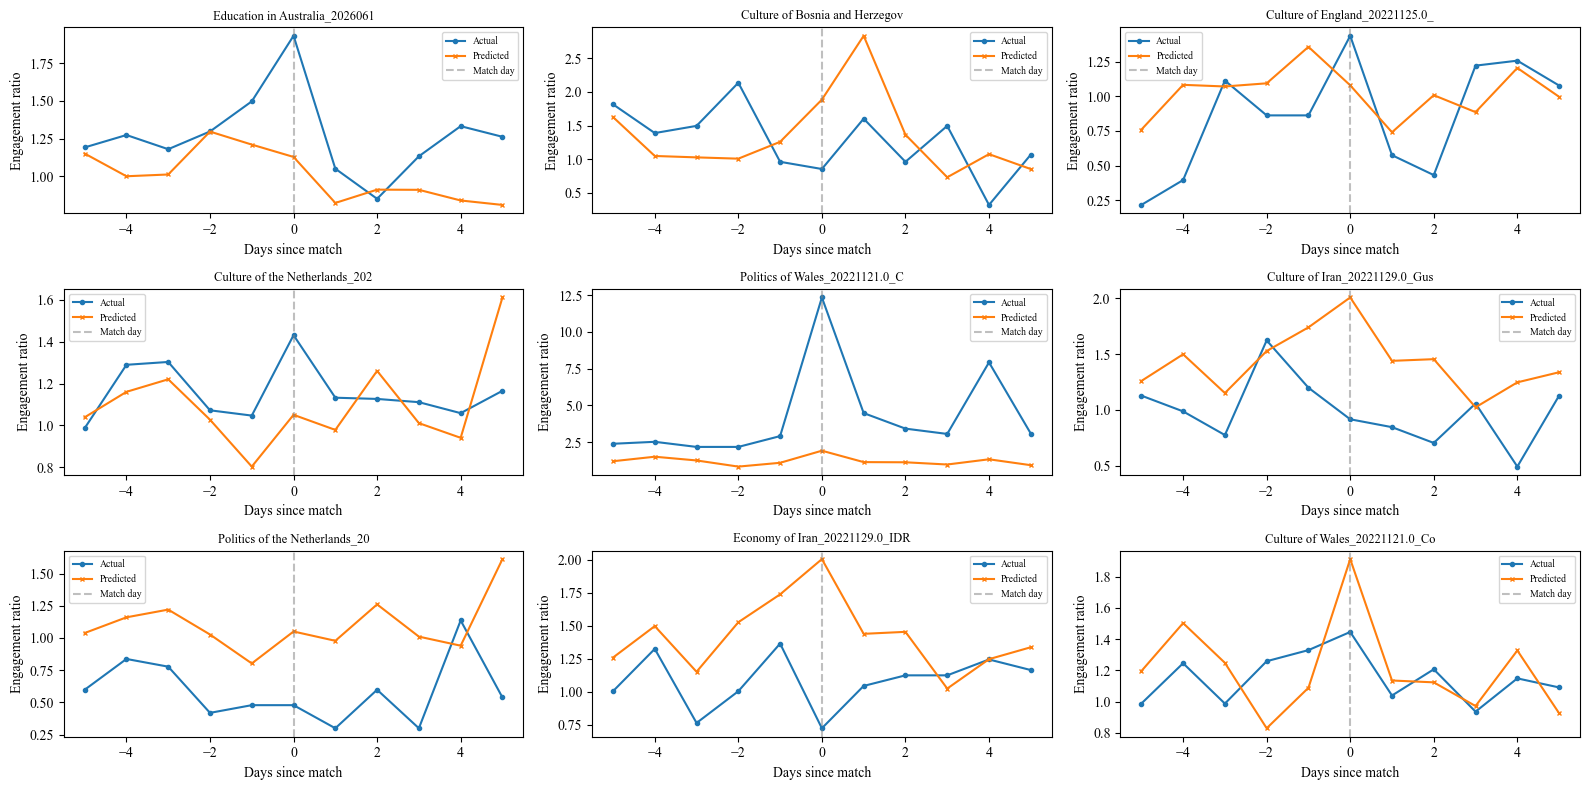

In [268]:


# Pick a handful of test articles to visualize
sample_article_ids = test_df_v2_clean['article_id'].drop_duplicates().sample(9, random_state=10)

fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()

for i, aid in enumerate(sample_article_ids):
    article_mask = test_df_v2_clean['article_id'] == aid
    article_data = test_df_v2_clean[article_mask].sort_values('days_since_match')
    
    # Get predictions for just this article's rows
    X_article = article_data[feature_cols_v2]
    y_actual = article_data['engagement_ratio']
    y_pred_article = np.exp(rf.predict(X_article))
    
    ax = axes[i]
    ax.plot(article_data['days_since_match'], y_actual, label='Actual', marker='o', markersize=3)
    ax.plot(article_data['days_since_match'], y_pred_article, label='Predicted', marker='x', markersize=3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='Match day')
    ax.set_title(aid[:30], fontsize=9)  # truncate long titles
    ax.set_xlabel('Days since match')
    ax.set_ylabel('Engagement ratio')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [269]:
# Per-article correlation between predicted and actual, averaged across articles
from scipy.stats import pearsonr

mae = mean_absolute_error(y_test_v2, y_pred_v2)
rmse = root_mean_squared_error(y_test_v2, y_pred_v2)
print(f"MAE: {mae}, RMSE: {rmse}")

article_corrs = []
for aid in test_df_v2_clean['article_id'].unique():
    mask = test_df_v2_clean['article_id'] == aid
    if mask.sum() > 2:  # need at least a few points for correlation to mean anything
        actual = y_test_v2[mask]
        pred = y_pred_v2[mask]
        if actual.std() > 0 and pred.std() > 0:
            r, _ = pearsonr(actual, pred)
            article_corrs.append(r)

print("Mean per-article correlation:", np.mean(article_corrs))

MAE: 0.6543139727727216, RMSE: 1.9759481630103468
Mean per-article correlation: 0.19934934252945885
